# Triangle-Sign vs. Central-Difference Jacobian (2D)

Central-difference `jacobian_det2D` averages partial derivatives over a 2Δ stencil, which can mask local folds whose gradient contributions cancel across neighbors.

The per-pixel two-triangle sign check (`triangle_sign_det2D`) computes the signed area of two triangles per pixel in the *warped* grid:

- **T1** at (x, y): vertices `(x, y)`, `(x−1, y+1)`, `(x, y+1)`
- **T2** at (x, y): vertices `(x, y)`, `(x, y+1)`, `(x+1, y)`

Positive = valid, zero = collapse, negative = flip. This notebook compares the two on a handful of synthetic fields and shows where central-diff misses folds.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import matplotlib.pyplot as plt

from dvfopt.jacobian import jacobian_det2D, triangle_sign_det2D, triangle_sign_count_negatives
from test_cases import make_deformation

### Warped-grid helper

Small helper used by both cases below. Draws the reference grid faintly + the warped quad grid in blue, and outlines cells where `min(T1, T2) <= 0` in dark blue.

In [2]:
def plot_warped_grid(ax, phi, title, highlight_folds=True):
    dy = phi[0]; dx = phi[1]
    Hh, Ww = dy.shape
    yy, xx = np.mgrid[:Hh, :Ww]
    gx = xx + dx; gy = yy + dy
    for i in range(Hh):
        ax.plot(xx[i], yy[i], color='#f0f0f0', lw=0.4)
    for j in range(Ww):
        ax.plot(xx[:, j], yy[:, j], color='#f0f0f0', lw=0.4)
    for i in range(Hh):
        ax.plot(gx[i], gy[i], color='#5b7fb5', lw=0.9)
    for j in range(Ww):
        ax.plot(gx[:, j], gy[:, j], color='#5b7fb5', lw=0.9)
    if highlight_folds:
        from dvfopt.jacobian import triangle_sign_areas2D
        tri = triangle_sign_areas2D(phi)
        bad = np.argwhere(tri.min(axis=0) <= 0)
        for (cy, cx) in bad:
            poly_x = [gx[cy, cx], gx[cy, cx+1], gx[cy+1, cx+1], gx[cy+1, cx], gx[cy, cx]]
            poly_y = [gy[cy, cx], gy[cy, cx+1], gy[cy+1, cx+1], gy[cy+1, cx], gy[cy, cx]]
            ax.plot(poly_x, poly_y, color='#d32f2f', lw=1.8)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

## Case 1: central-diff failure (`dx[3,3]=+1.2, dx[3,4]=−1.2`)

The classic "bowtie" artifact. Every pixel's central-difference Jacobian is positive, yet two neighboring quad cells are geometrically folded.

In [3]:
H = W = 7
dy = np.zeros((H, W))
dx = np.zeros((H, W))
dx[3, 3] = +1.2
dx[3, 4] = -1.2
phi = np.stack([dy, dx])

j = jacobian_det2D(phi)[0]
signs = triangle_sign_det2D(phi)  # (2, H-1, W-1)

print(f'central-diff  :  min={j.min():+.3f}   max={j.max():+.3f}   n_neg={(j <= 0).sum()}')
print(f'triangle sign :  T1 n_neg={(signs[0] <= 0).sum()}  T2 n_neg={(signs[1] <= 0).sum()}  total={triangle_sign_count_negatives(phi)}')

central-diff  :  min=+0.400   max=+1.600   n_neg=0
triangle sign :  T1 n_neg=1  T2 n_neg=1  total=2


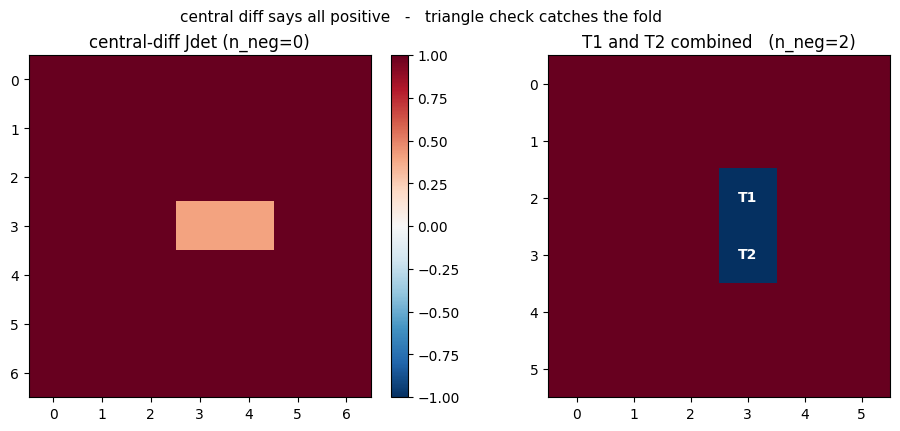

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), layout='constrained')

ax = axes[0]
im = ax.imshow(j, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_title(f'central-diff Jdet (n_neg={(j <= 0).sum()})')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Combined T1/T2 sign heatmap: color by the worst-of-two triangle sign per
# cell, and label each flipped cell with which triangle (T1, T2, or both).
combined = np.minimum(signs[0], signs[1])
ax = axes[1]
ax.imshow(combined, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_title(f'T1 and T2 combined   (n_neg={int((combined <= 0).sum())})')
bad_cells = np.argwhere((signs[0] <= 0) | (signs[1] <= 0))
for (cy, cx) in bad_cells:
    parts = []
    if signs[0, cy, cx] <= 0:
        parts.append('T1')
    if signs[1, cy, cx] <= 0:
        parts.append('T2')
    ax.text(cx, cy, chr(10).join(parts), ha='center', va='center',
             color='white', fontsize=10, fontweight='bold')

plt.suptitle('central diff says all positive   -   triangle check catches the fold', fontsize=11)
plt.show()


### Warped grid view

Same bowtie, now as a warped quad grid. Central-diff gave us a uniformly red heatmap above; here the two folded quads are visibly self-crossed X shapes, outlined in dark blue. Heatmaps describe it; the grid *shows* it.

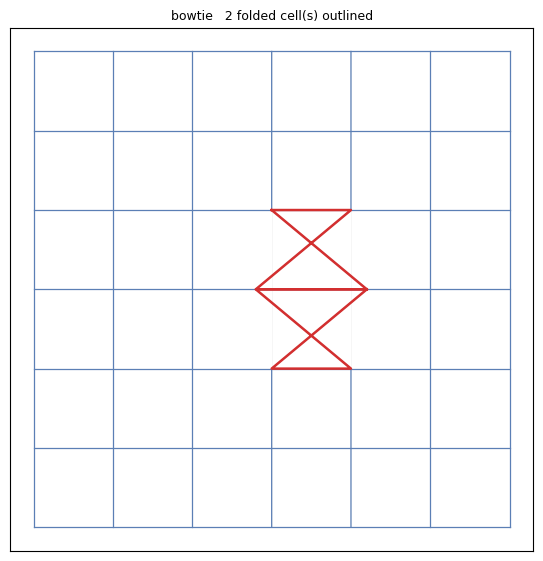

In [5]:
fig, ax = plt.subplots(figsize=(5.5, 5.5), layout='constrained')
plot_warped_grid(ax, phi, f'bowtie   {(signs <= 0).any(axis=0).sum()} folded cell(s) outlined')
plt.show()

## Case 2: fold test-case library

Run on `test_cases` entries with known folds. Report neg counts for central-diff vs. triangle T1/T2/union, and show a disagreement map: pixels where central-diff is positive but a triangle flipped.

In [6]:
CASES = [
    '01a_10x10_crossing',
    '01b_10x10_opposite',
    '03b_10x10_crossing',
    '03c_20x20_opposite',
    '03d_20x20_crossing',
    '01c_20x40_edges',
]

print(f"{'case':<22s}  {'n_px':>6s}  {'neg_CD':>7s}  {'min_CD':>8s}  {'neg_T1':>7s}  {'neg_T2':>7s}  {'neg_any':>8s}")
print('-' * 76)

results = {}
for key in CASES:
    deformation, *_ = make_deformation(key)
    phi = np.stack([deformation[1, 0], deformation[2, 0]])
    j = jacobian_det2D(phi)[0]
    signs = triangle_sign_det2D(phi)
    n_cd = int((j <= 0).sum())
    n_t1 = int((signs[0] <= 0).sum())
    n_t2 = int((signs[1] <= 0).sum())
    n_any = int(((signs <= 0).any(axis=0)).sum())
    H, W = j.shape
    print(f'{key:<22s}  {H*W:>6d}  {n_cd:>7d}  {j.min():+8.3f}  {n_t1:>7d}  {n_t2:>7d}  {n_any:>8d}')
    results[key] = (phi, j, signs)

case                      n_px   neg_CD    min_CD   neg_T1   neg_T2   neg_any
----------------------------------------------------------------------------
Building data for Laplacian Sparse Matrix A (optimized)
Creating Laplacian Sparse Matrix A
01a_10x10_crossing         100        9    -1.029       12       12        16
Building data for Laplacian Sparse Matrix A (optimized)


Creating Laplacian Sparse Matrix A
01b_10x10_opposite         100        6    -1.174        5        5         8
Building data for Laplacian Sparse Matrix A (optimized)
Creating Laplacian Sparse Matrix A


03b_10x10_crossing         100       18    -1.039       16       12        24
Building data for Laplacian Sparse Matrix A (optimized)
Creating Laplacian Sparse Matrix A
03c_20x20_opposite         400       34    -1.432       26       32        42
Building data for Laplacian Sparse Matrix A (optimized)


Creating Laplacian Sparse Matrix A
03d_20x20_crossing         400       30    -1.025       36       36        72
Building data for Laplacian Sparse Matrix A (optimized)
Creating Laplacian Sparse Matrix A


01c_20x40_edges            800       32    -1.388       34       34        49


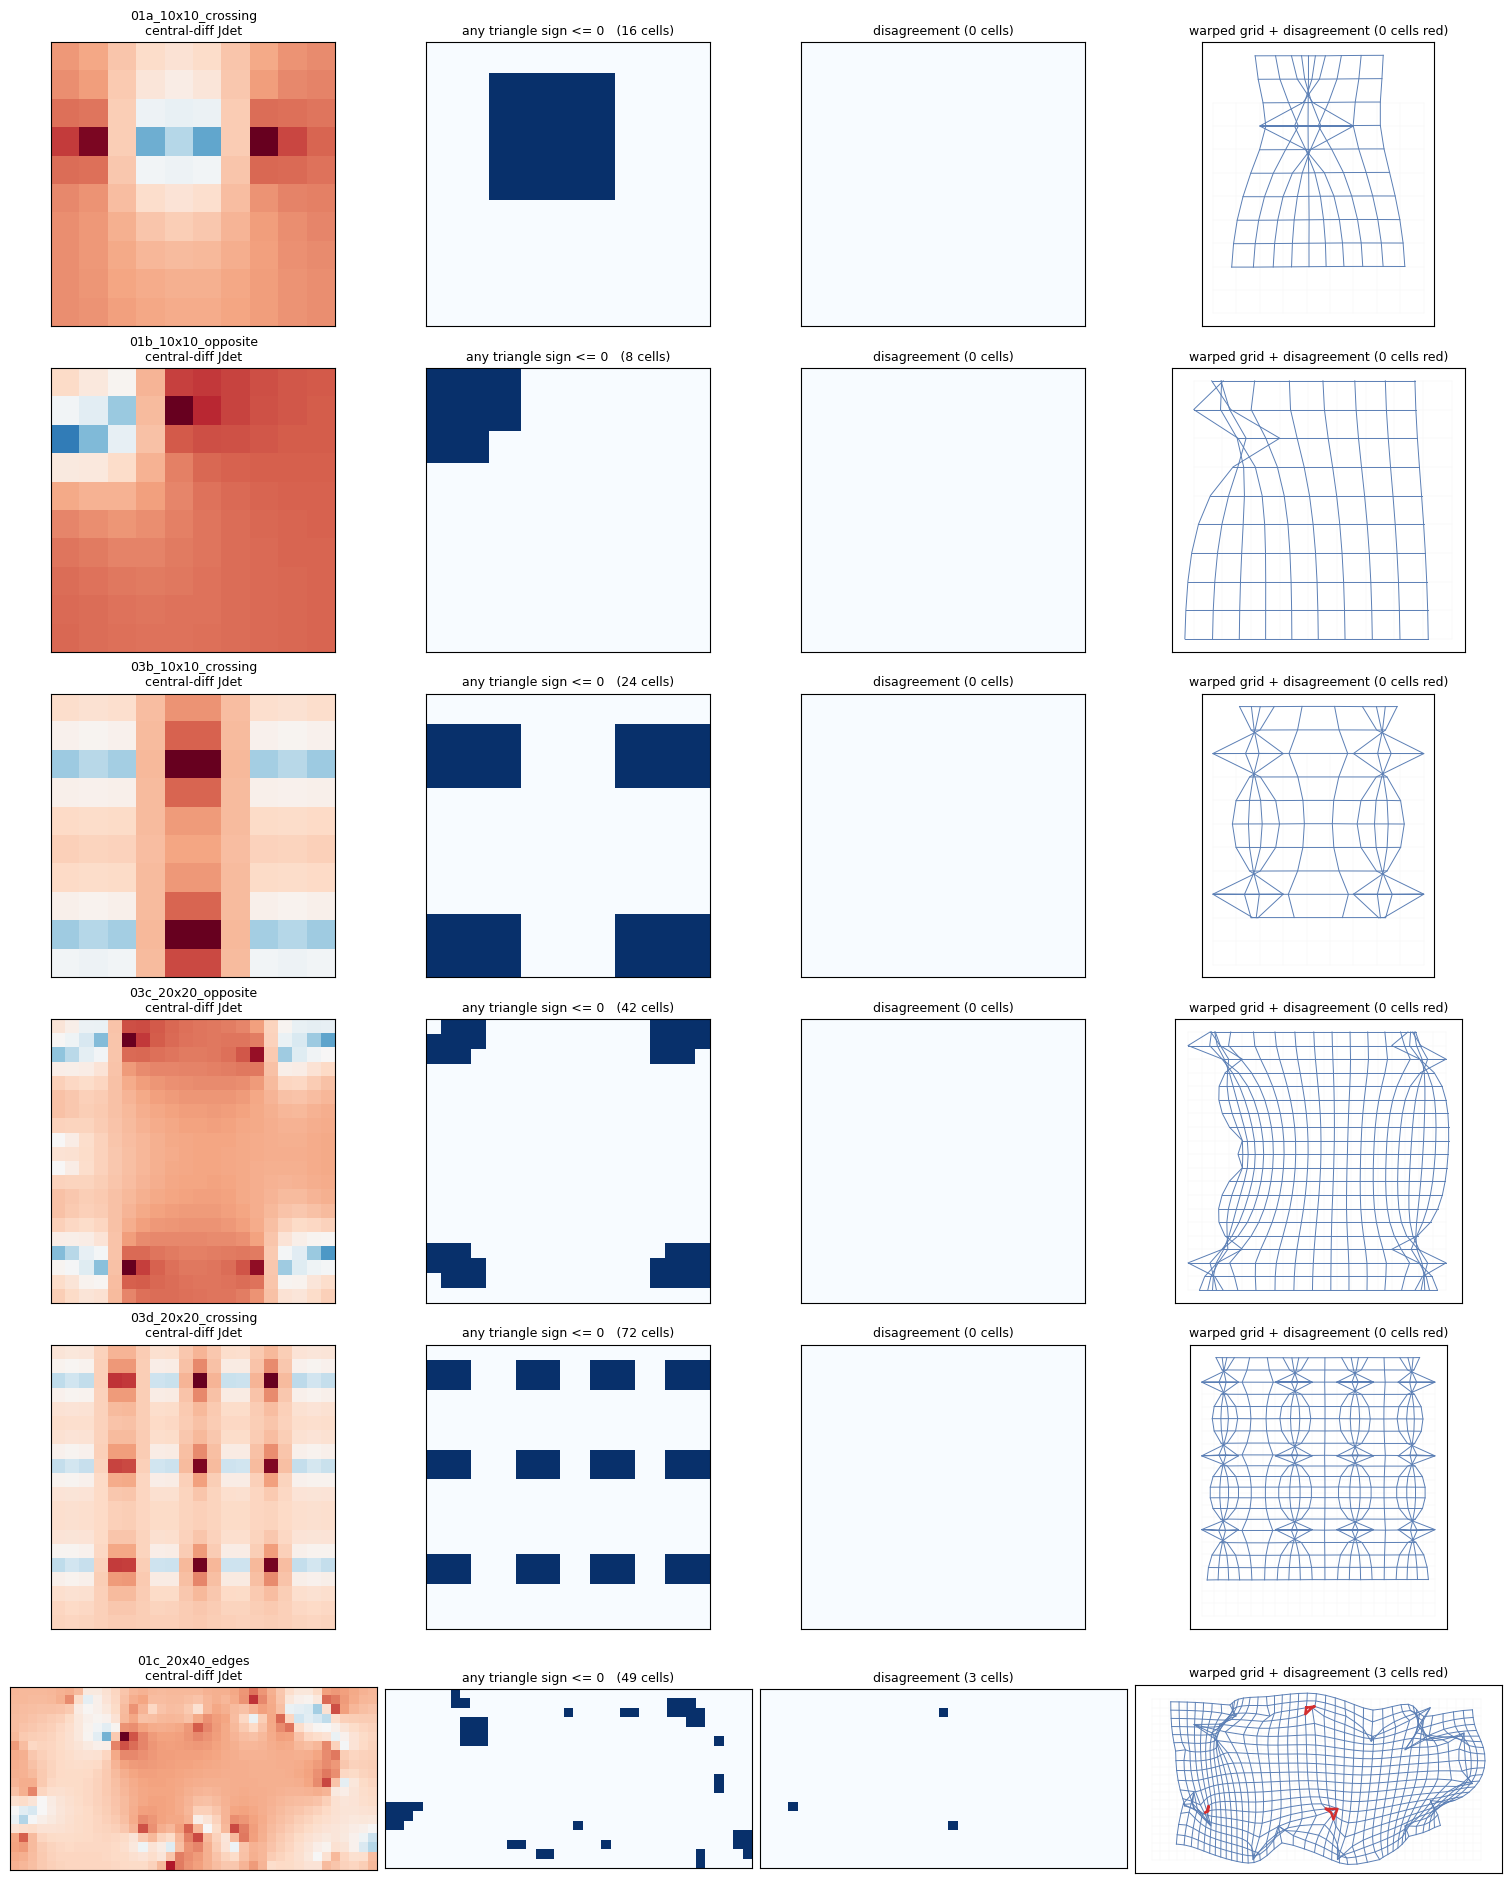

In [7]:
def disagreement_map(j, signs):
    """Cells where central-diff says fine but a triangle says fold."""
    cd_pos = (j > 0)[:-1, :-1] & (j > 0)[1:, :-1] & (j > 0)[:-1, 1:] & (j > 0)[1:, 1:]
    tri_bad = (signs <= 0).any(axis=0)
    return cd_pos & tri_bad


def _plot_warped_with_mask(ax, phi, mask, title):
    """Warped quad grid; cells flagged in `mask` outlined in dark red."""
    dy = phi[0]; dx = phi[1]
    Hh, Ww = dy.shape
    yy, xx = np.mgrid[:Hh, :Ww]
    gx = xx + dx; gy = yy + dy
    for i in range(Hh):
        ax.plot(xx[i], yy[i], color='#f4f4f4', lw=0.3)
    for j in range(Ww):
        ax.plot(xx[:, j], yy[:, j], color='#f4f4f4', lw=0.3)
    for i in range(Hh):
        ax.plot(gx[i], gy[i], color='#5b7fb5', lw=0.7)
    for j in range(Ww):
        ax.plot(gx[:, j], gy[:, j], color='#5b7fb5', lw=0.7)
    for (cy, cx) in np.argwhere(mask):
        px = [gx[cy, cx], gx[cy, cx+1], gx[cy+1, cx+1], gx[cy+1, cx], gx[cy, cx]]
        py = [gy[cy, cx], gy[cy, cx+1], gy[cy+1, cx+1], gy[cy+1, cx], gy[cy, cx]]
        ax.plot(px, py, color='#d32f2f', lw=1.8)
    ax.set_aspect('equal'); ax.invert_yaxis()
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])


n = len(CASES)
fig, axes = plt.subplots(n, 4, figsize=(15, 3.2 * n), layout='constrained')
for i, key in enumerate(CASES):
    phi, j, signs = results[key]
    tri_any_neg = (signs <= 0).any(axis=0).astype(int)
    disagree = disagreement_map(j, signs)

    axes[i, 0].imshow(j, cmap='RdBu_r', vmin=-abs(j).max(), vmax=abs(j).max())
    axes[i, 0].set_title(f'{key}' + chr(10) + 'central-diff Jdet', fontsize=9)
    axes[i, 1].imshow(tri_any_neg, cmap='Blues', vmin=0, vmax=1)
    axes[i, 1].set_title(f'any triangle sign <= 0   ({int(tri_any_neg.sum())} cells)', fontsize=9)
    axes[i, 2].imshow(disagree.astype(int), cmap='Blues', vmin=0, vmax=1)
    axes[i, 2].set_title(f'disagreement ({int(disagree.sum())} cells)', fontsize=9)
    _plot_warped_with_mask(axes[i, 3], phi, disagree,
                            f'warped grid + disagreement ({int(disagree.sum())} cells red)')
    for ax in axes[i, :3]:
        ax.set_xticks([]); ax.set_yticks([])

plt.show()


### Warped grid views across the fold library

One panel per test case. Cells where `min(T1, T2) <= 0` are outlined in dark blue. Contrast with the `central-diff Jdet` heatmap column above: the CD heatmap typically shows *fewer* blue pixels than there are folded cells in the warped grid, because central-diff's 2-delta stencil averages across neighbors and misses the local swap.

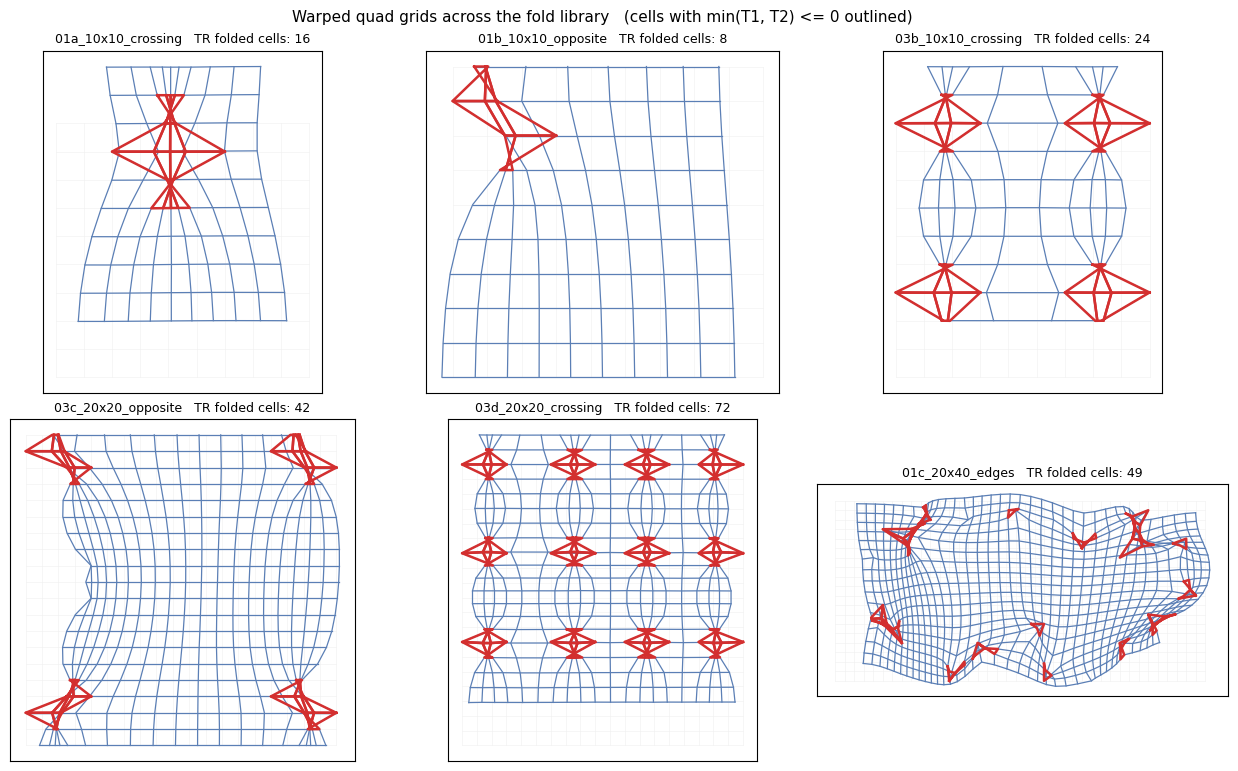

In [8]:
n = len(CASES)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4.2 * cols, 3.8 * rows), layout='constrained', squeeze=False)
for i, key in enumerate(CASES):
    r, c = divmod(i, cols)
    phi, j, signs = results[key]
    n_tr = int((signs <= 0).any(axis=0).sum())
    plot_warped_grid(axes[r, c], phi, f'{key}   TR folded cells: {n_tr}')
# hide any leftover empty panels
for k in range(n, rows * cols):
    r, c = divmod(k, cols)
    axes[r, c].set_visible(False)
plt.suptitle('Warped quad grids across the fold library   (cells with min(T1, T2) <= 0 outlined)', fontsize=11)
plt.show()

## Summary

- On the 7×7 bowtie (Case 1), central-diff reports all-positive Jdet while the triangle check flips on at least one of T1/T2 in the folded cells. This is the textbook central-diff failure mode.
- On the `test_cases` fold library (Case 2), neg counts are similar between central-diff and the triangle-any-negative check on most cases (both detect the fold). The disagreement column highlights cells where the triangle check catches something central-diff misses — usually at fold boundaries where central-diff's 2Δ averaging smears the sign.
- The triangle check uses the TR-BL diagonal. The existing `triangulated_shoelace_det2D` uses TL-BR; for worst-case coverage use `triangle_det2D` (4 triangles per cell).

## Per-pixel debug visualization

`dvfopt.viz.plot_problematic_triangles` finds every pixel with a flipped or collapsed triangle and renders a per-pixel plot showing the warped neighborhood, both T1/T2 triangles outlined and filled by sign, and a text panel with the cross-product formula and every numeric input. Use it as a debug toggle inside iterative solvers:

```python
if debug:
    plot_problematic_triangles(phi_xy, title=f"iter {k}")
```

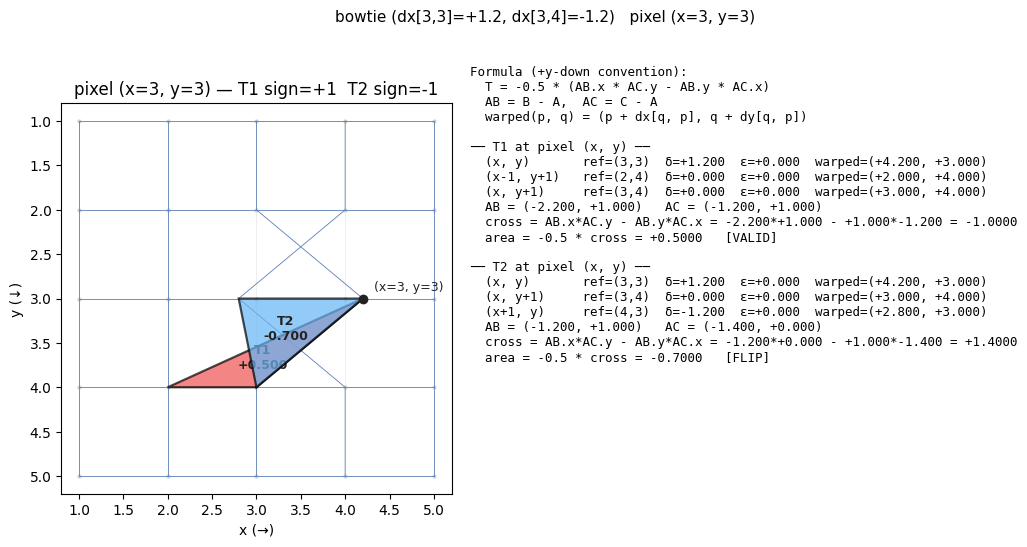

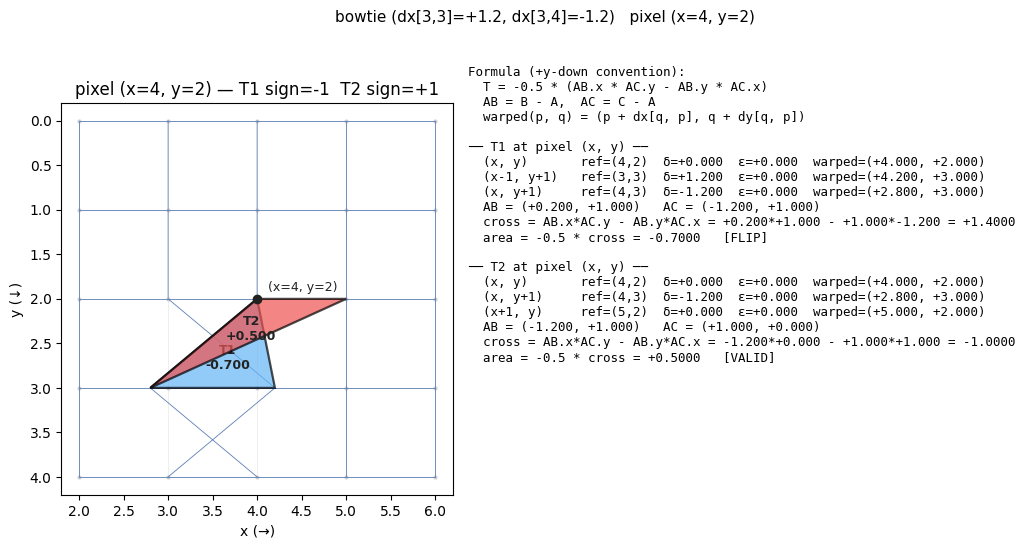

In [9]:
from dvfopt.viz import plot_problematic_triangles

# Reuse the bowtie case (Case 1) — central-diff missed it, triangle check flagged 2 pixels.
H = W = 7
dx = np.zeros((H, W)); dy = np.zeros((H, W))
dx[3, 3] = +1.2
dx[3, 4] = -1.2
phi = np.stack([dy, dx])

_ = plot_problematic_triangles(phi, title='bowtie (dx[3,3]=+1.2, dx[3,4]=-1.2)')